# Transfer Learning (TF 1.14) — InceptionV3 for Surface Defect Classification

**Framework:** TensorFlow **1.14.0** (Keras API)  
**Dataset:** NEU-DET (steel surface defects)  
**Method:** Transfer learning with **InceptionV3** + lightweight classifier head, optional partial fine-tuning.

This notebook alternates **concise teaching notes** with **small code sections**.  

## 1. Imports

We use TensorFlow/Keras for training, and scikit-learn for evaluation.
In TF 1.14, module availability can vary; we include a safe fallback for importing InceptionV3.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
#print("TensorFlow version:", tf.__version__)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

# Safe import fallback (TF 1.x environments can differ)
try:
    from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
except Exception as e:
    print("tf.keras Inception import failed, trying standalone Keras:", e)
    from keras.applications.inception_v3 import InceptionV3, preprocess_input


C:\Users\Somying\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
C:\Users\Somying\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
C:\Users\Somying\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
C:\Users\Somying\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:519: FutureWarnin

## 2. Paths and configuration

Keep run-critical settings at the top.  
InceptionV3 is commonly trained at 299×299, but can accept other square sizes when `include_top=False`.


In [2]:
train_path = './NEU-DET-A/train'
test_path  = './NEU-DET-A/test'

IMG_SIZE = (299, 299)
BATCH_SIZE = 32
SEED = 42


## 3. Data loading and augmentation

Training augmentation improves robustness by simulating small changes in:

    rotation
    translation (shift)
    horizontal flip

Validation and test must remain clean (no augmentation), otherwise the metric becomes harder to interpret.

Important engineering rule:

    The test set must remain unseen until the end.


Further reading:
- ImageDataGenerator: https://keras.io/api/preprocessing/image/


In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=(0.7, 1.3),
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.5
)

#Put seed to improve reproducibility of shuffling/augmentation, but deep learning can still have small run-to-run variation.'
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)
print("NUM_CLASSES:", NUM_CLASSES)


Found 1260 images belonging to 6 classes.
Found 270 images belonging to 6 classes.
Found 270 images belonging to 6 classes.
NUM_CLASSES: 6


## 4. Sanity check: class label mapping

A frequent failure mode is inconsistent class indexing across splits.
We verify that train/val/test share the same mapping.

We also inspect class balance (imbalanced classes can cause unstable validation accuracy)


In [4]:
print("Train:", train_generator.class_indices)
print("Val  :", val_generator.class_indices)
print("Test :", test_generator.class_indices)

# Class balance (counts per class in training set)
from collections import Counter
counts = Counter(train_generator.classes)
print('Train counts:', counts)

Train: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
Val  : {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
Test : {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
Train counts: Counter({0: 210, 1: 210, 2: 210, 3: 210, 4: 210, 5: 210})


## 5. Model construction (feature extraction)

We load a pretrained InceptionV3 backbone (ImageNet), freeze it, and train only a small head.

Design choices:
- GlobalAveragePooling2D reduces parameters vs Flatten
- Dropout mitigates overfitting on small datasets

Further reading:
- Transfer learning guide: https://keras.io/guides/transfer_learning/
- Global Average Pooling: https://www.geeksforgeeks.org/deep-learning/cnn-introduction-to-pooling-layer/


In [5]:
# Head imports (support both tf.keras and standalone Keras)
try:
    from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
    from tensorflow.keras.models import Model
except Exception:
    from keras.layers import GlobalAveragePooling2D, Dense, Dropout
    from keras.models import Model

#1. Load pre-trained ImageNet weights
base_model = InceptionV3(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)

#2. Freeze backbone (Freeze the pre-trained weights)
base_model.trainable = False 

#3. Adding classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.summary()


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 299, 299, 3) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 149, 149, 32) 864         input_1[0][0]                    
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 149, 149, 32) 96          conv2d[0][0]                     
__________________________________________________________________________________________________
activation (Activation)         (None, 149, 149, 32) 0           batch_norm

## 6. Compile and callbacks (TF 1.14 naming)

TF 1.14 often logs metrics as `acc` / `val_acc`.  
We monitor **val_acc** for EarlyStopping and ReduceLROnPlateau.


In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    mode='min',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_defect_model.keras', # Name of the file to save
    monitor='val_acc',      # Watch validation accuracy
    save_best_only=True,         # Only overwrite if accuracy improves
    mode='max',                  # We want the maximum accuracy
    verbose=1                    # Prints a message when a new best is saved
)

## 7. Train (feature extraction stage)

Backbone is frozen; only the head learns. This is usually the most stable stage.


In [7]:
history = model.fit_generator(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop, lr_reduce]
)


Epoch 1/40
39/40 [============================>.] - ETA: 4s - loss: 1.4387 - acc: 0.4503
Epoch 00001: val_acc improved from -inf to 0.70000, saving model to best_defect_model.keras
40/40 [==============================] - 221s 6s/step - loss: 1.4285 - acc: 0.4540 - val_loss: 1.1840 - val_acc: 0.7000
Epoch 2/40
39/40 [============================>.] - ETA: 4s - loss: 0.9118 - acc: 0.6865
Epoch 00002: val_acc improved from 0.70000 to 0.74815, saving model to best_defect_model.keras
40/40 [==============================] - 189s 5s/step - loss: 0.9001 - acc: 0.6921 - val_loss: 0.9777 - val_acc: 0.7481
Epoch 3/40
39/40 [============================>.] - ETA: 4s - loss: 0.6372 - acc: 0.7964
Epoch 00003: val_acc improved from 0.74815 to 0.77407, saving model to best_defect_model.keras
40/40 [==============================] - 186s 5s/step - loss: 0.6354 - acc: 0.7960 - val_loss: 0.7706 - val_acc: 0.7741
Epoch 4/40
39/40 [============================>.] - ETA: 4s - loss: 0.5457 - acc: 0.8265
Ep

## 8. Training curves

We plot accuracy/loss. The helper function supports both TF1 (`acc`) and TF2 (`accuracy`) history keys.


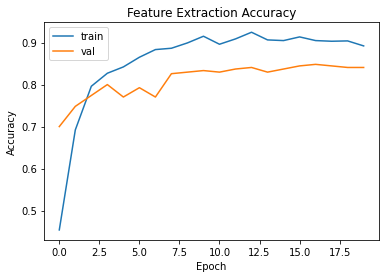

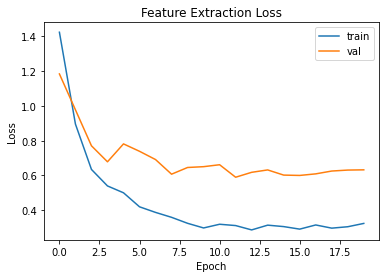

In [10]:
from tensorflow.keras.models import load_model

# Load the best version saved by the callback
model = load_model('best_defect_model.keras') 

def plot_history(h, title_prefix=""):
    hist = h.history
    acc = hist.get('accuracy', hist.get('acc', []))
    val_acc = hist.get('val_accuracy', hist.get('val_acc', []))
    loss = hist.get('loss', [])
    val_loss = hist.get('val_loss', [])

    plt.figure(figsize=(6,4))
    plt.plot(acc, label='train')
    plt.plot(val_acc, label='val')
    plt.title(f'{title_prefix} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(loss, label='train')
    plt.plot(val_loss, label='val')
    plt.title(f'{title_prefix} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_history(history, title_prefix="Feature Extraction")


## 9. Evaluation on unseen test set

We report confusion matrix and class-wise precision/recall/F1.


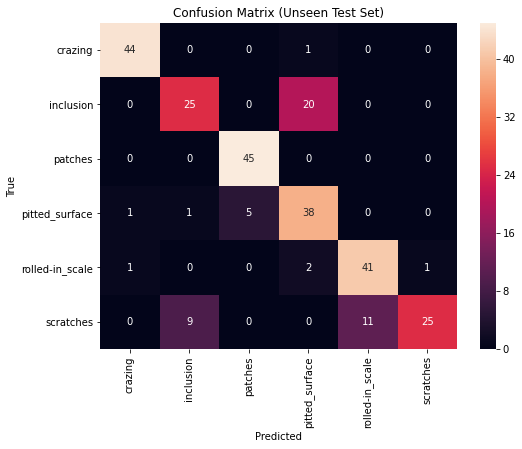

                 precision    recall  f1-score   support

        crazing       0.96      0.98      0.97        45
      inclusion       0.71      0.56      0.63        45
        patches       0.90      1.00      0.95        45
 pitted_surface       0.62      0.84      0.72        45
rolled-in_scale       0.79      0.91      0.85        45
      scratches       0.96      0.56      0.70        45

       accuracy                           0.81       270
      macro avg       0.82      0.81      0.80       270
   weighted avg       0.82      0.81      0.80       270



In [11]:
test_generator.reset()
probs = model.predict_generator(test_generator)
y_pred = np.argmax(probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Unseen Test Set)')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


## 10. Optional fine-tuning (partial unfreezing)

Fine-tuning adapts high-level features to industrial textures. Apply conservatively:
- unfreeze a small tail (e.g., 10–30 layers)
- use a small learning rate (1e-4)
- stop if overfitting increases


Epoch 1/30
39/40 [============================>.] - ETA: 4s - loss: 0.3186 - acc: 0.9007
Epoch 00001: val_acc did not improve from 0.84815
40/40 [==============================] - 194s 5s/step - loss: 0.3222 - acc: 0.9000 - val_loss: 0.6056 - val_acc: 0.8370
Epoch 2/30
39/40 [============================>.] - ETA: 4s - loss: 0.2882 - acc: 0.9267
Epoch 00002: val_acc did not improve from 0.84815
40/40 [==============================] - 193s 5s/step - loss: 0.2869 - acc: 0.9270 - val_loss: 0.6855 - val_acc: 0.8296
Epoch 3/30
39/40 [============================>.] - ETA: 4s - loss: 0.3290 - acc: 0.9096
Epoch 00003: val_acc did not improve from 0.84815
40/40 [==============================] - 192s 5s/step - loss: 0.3298 - acc: 0.9079 - val_loss: 0.6572 - val_acc: 0.8333
Epoch 4/30
39/40 [============================>.] - ETA: 4s - loss: 0.2966 - acc: 0.9023
Epoch 00004: val_acc did not improve from 0.84815

Epoch 00004: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
40

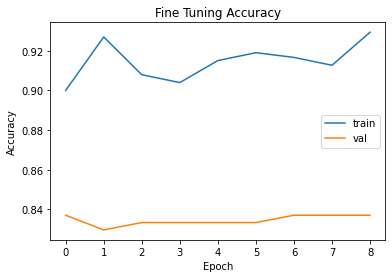

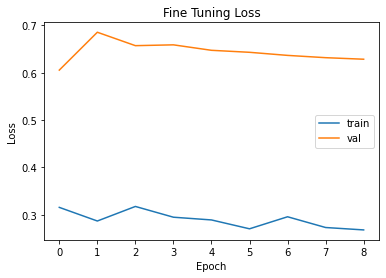

In [12]:
N = 10  # conservative default
for layer in base_model.layers[-N:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit_generator(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop, lr_reduce]
)

plot_history(history_fine, title_prefix="Fine Tuning")


## 11. Notes on overfitting (practical adjustments)

If overfitting persists:
- Increase dropout (0.5 is already a strong default)
- Reduce head size (Dense 128 → 64)
- Fine-tune fewer layers (smaller N)
- Slightly increase augmentation (keep realistic)


## 12. Summary

- InceptionV3 transfer learning is a strong baseline for texture-rich defect data
- Correct preprocessing (matching backbone) is essential
- Evaluate with confusion matrix + per-class metrics
- Fine-tune conservatively on small datasets
